# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
%pip install datasets==4.5.0 ipykernel==6.31.0 ipywidgets==8.1.5 notebook==7.5.5 matplotlib==3.9.4 numpy==2.0.2 seaborn==0.13.2 torch==2.8.0


In [2]:
import os
import random
import re
from collections import Counter
from pathlib import Path

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn

RANDOM_SEED = 42
DATASET_NAME = "SetFit/sst2"
HF_TOKEN_ENV_VAR = "HF_TOKEN"
HF_TOKEN_LEGACY_ENV_VAR = "HUGGING_FACE_HUB_TOKEN"
ENV_FILE_CANDIDATES = (Path("env"), Path("../env"))
SAMPLE_PREVIEW_COUNT = 5
VOCAB_SIZE = 10_000
RANDOM_INIT_SCALE = 0.01
CLASSIFICATION_THRESHOLD = 0.5
DEFAULT_LR = 0.01
DEFAULT_EPOCHS = 20
DEFAULT_BATCH_SIZE = 100
ZERO_INIT_MODE = "zeros"
RANDOM_INIT_MODE = "random"
NO_PENALTY = "none"
NO_REG_LAMBDA = 0.0
METRIC_NAME = "accuracy"
METRIC_EPS = 1e-15

LEARNING_RATES = [0.01, 0.03, 0.1, 0.3, 1.0]
BATCH_SIZES = [50, 100, 200]
SWEEP_EPOCHS = 20
SWEEP_INIT_MODE = RANDOM_INIT_MODE
COMPETITIVE_TOL = 0.05

L1_METRIC_NAME = METRIC_NAME
L1_LR = 0.1
L1_BATCH_SIZE = 100
L1_EPOCHS = 20
L1_TOLERANCE = 1e-7
INIT_COMPARE_LAMBDA = 1e-2
REG_LAMBDAS = [0, 1e-4, 1e-3, 1e-2, 1e-1]
INIT_MODES = [ZERO_INIT_MODE, RANDOM_INIT_MODE]
FEATURE_SHRINKAGE_MIN_ABS = 1e-5
TOP_FEATURE_COUNT = 5

OPTIMIZER_START = torch.tensor([-1.5, 1.5])
BOWL_XLIM = (-2, 2)
BOWL_YLIM = (-2, 2)
CAMEL_XLIM = (-3, 3)
CAMEL_YLIM = (-2, 2)
BOWL_OPTIMIZER_KWARGS = {
    "GD": {"lr": 0.1, "n_steps": 150},
    "Momentum": {"lr": 0.08, "beta": 0.9, "n_steps": 150},
    "AdaGrad": {"lr": 0.8, "n_steps": 150},
    "Adam": {"lr": 0.15, "n_steps": 150},
}
CAMEL_OPTIMIZER_KWARGS = {
    "GD": {"lr": 0.005, "n_steps": 2000},
    "Momentum": {"lr": 0.01, "beta": 0.95, "n_steps": 2000},
    "AdaGrad": {"lr": 0.2, "n_steps": 2000},
    "Adam": {"lr": 0.03, "n_steps": 2000},
}
CAMEL_SENSITIVITY_STARTS = {
    "(-2.0, -1.5)": (-2.0, -1.5),
    "(-1.0, 1.0)": (-1.0, 1.0),
}

TOY_ALPHA = 0.35
TOY_REG_LAMBDA = 0.25
TOY_N_STEPS = 35
TOY_W0 = 1.0
TOY_TARGETS = {
    "Weak feature": 0.05,
    "Strong feature": 1.50,
}
ZERO_HIT_TOLERANCE = 1e-12

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

PLOT_PALETTE = sns.color_palette("colorblind", 8)
METRIC_CMAP = sns.light_palette("#2563eb", as_cmap=True)
LOSS_CMAP = sns.light_palette("#dc2626", as_cmap=True)
CONTOUR_CMAP = sns.color_palette("mako", as_cmap=True)
OPTIMIZER_COLORS = {
    "GD": PLOT_PALETTE[0],
    "Momentum": PLOT_PALETTE[1],
    "AdaGrad": PLOT_PALETTE[2],
    "Adam": PLOT_PALETTE[3],
}
REGULARIZATION_COLORS = {
    "L1 subgradient GD": PLOT_PALETTE[0],
    "Proximal GD (L1)": PLOT_PALETTE[2],
    "L2 gradient GD": PLOT_PALETTE[1],
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "figure.facecolor": "white",
    "axes.facecolor": "#fbfbfd",
    "axes.edgecolor": "#d0d5dd",
    "axes.linewidth": 0.9,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e5e7eb",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.85,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "600",
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.color": "#344054",
    "ytick.color": "#344054",
    "text.color": "#111827",
    "axes.labelcolor": "#111827",
    "axes.titlecolor": "#111827",
    "legend.frameon": True,
    "legend.fancybox": True,
    "legend.framealpha": 0.95,
    "legend.facecolor": "white",
    "legend.edgecolor": "#e5e7eb",
    "lines.linewidth": 2.4,
    "lines.markersize": 5,
})

for env_file in ENV_FILE_CANDIDATES:
    if env_file.exists():
        for env_line in env_file.read_text().splitlines():
            env_line = env_line.strip()
            if not env_line or env_line.startswith("#") or "=" not in env_line:
                continue

            key, value = env_line.split("=", 1)
            key = key.strip()
            if key.startswith("export "):
                key = key[len("export "):].strip()

            os.environ.setdefault(key, value.strip().strip('"').strip("'"))
        break

if os.environ.get(HF_TOKEN_ENV_VAR) and not os.environ.get(HF_TOKEN_LEGACY_ENV_VAR):
    os.environ[HF_TOKEN_LEGACY_ENV_VAR] = os.environ[HF_TOKEN_ENV_VAR]


In [3]:
hf_token = os.environ.get(HF_TOKEN_ENV_VAR) or os.environ.get(HF_TOKEN_LEGACY_ENV_VAR)
sst2 = load_dataset(DATASET_NAME, token=hf_token)

data_train = sst2['train']
data_val = sst2['validation']


README.md:   0%|          | 0.00/378 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/136k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6920 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [4]:

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



Map:   0%|          | 0/6920 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [5]:

random.seed(RANDOM_SEED)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for _ in range(SAMPLE_PREVIEW_COUNT):
  r = random.randint(0, len(data_train) - 1)
  print(f"{data_train[r]['label_text']} Text: {data_train[r]['clean_text']}")


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")


size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive .
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one .
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful .
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy .
positive Text: the closest thing to the experience of space travel

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [6]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=VOCAB_SIZE):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [7]:

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f"Example tokens : {tokenize(data_train['clean_text'][0])}")

print(f"Length of tokens: {len(tokenize(data_train['clean_text'][0]))}")
print(f'Length of non-zero entries: {len(indices[0])}')


Vocabulary size: 10000


Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [8]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch (70 points)**

#### **Task 1.1 - Binary vs. Softmax Formulation and Numerical Stability of Cross-Entropy Loss (10 points)**



In this task, you will explore two ways to formulate the loss function for a classification problem and understand why numerical stability is important.

**a. Binary formulation**

   In the binary formulation, the model has:

   * a single output
   * sigmoid activation
   * binary cross-entropy loss

   This produces a probability: P(y=1|x)

   A prediction is then obtained using a threshold:
   * predict class 1 if p>0.5
   * otherwise predict class 0

   For binary logistic regression, the standard loss function is the **binary cross-entropy loss**:

   $L= -\frac{1}{N}\sum_{i=1}^N[y_ilog(\hat{y_i})+(1-y_i)log(1-\hat{y_i})]$

   where $\hat{y_i}$ is the predicted probability after applying sigmoid.

   Since this loss contains both: $log(\hat{y})$ and $log(1-\hat{y})$ , numerical problems may appear if $\hat{y_i}$ becomes extremely close to 0 or 1.

   A stable implementation should therefore clamp the predicted probabilities:
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```

**Note:** the threshold 0.5 is used only to convert probabilities into class predictions for evaluation.
It must not be used inside the loss function.

**b. Softmax formulation**

  Now, we will reformulate the same problem as a 2-class classification problem using softmax (This formulation is more general and can also be used for more than 2 classes.).

  **Step 1 — Convert labels to one-hot encoding**

  In our dataset the labels are either 1 or 0 (i.e positive or negetive). To use softmax will require us to convert the labels into a one-hot representation:
  * class 0 ---> [1,0]
  * class 1 ---> [0,1]

  Now our model will output 2 outputs instead of 1 and we will require to apply softmax to get the probability of class 0 vs. class 1.

  **Step 2 - Implementing softmax and log-loss**

   This can be implemented in two ways:

  1. **Naive version:**

     Given logits z = [$z_1,z_2,...,z_k$]

     softmax($z_i$) = $\frac{\exp(z_i)}{\sum_j\exp(z_j)}$


  2. **Stable version:**

     softmax($z_i$) = $\frac{\exp(z_i-max(z))}{\sum_j\exp(z_j-max(z))}$

   Than the cross entropy loss for the true class y is :

   **L = -log(softmax($z_y$))**

   or equivalently, for one-hot labels:

   **$L= -\sum_{c=1}^Ky_clog(\hat{y_c})$**

**Task**

A. Conceptual questions

For both the binary and softmax formulations, explain:

* Why do we need numerical stability? Where can the naive implementation fail?
* Why does the stability transformation not change the final softmax probabilities?
* Why does this transformation improve numerical stability?

B. Implementation
1. Implement a binary cross-entropy loss function for the binary formulation.
2. Make sure your implementation is numerically stable.

**Answer**

* We need numerical stability because both formulations use operations that can blow up at extreme values. In binary cross-entropy, probabilities extremely close to 0 or 1 make `log(\hat{y})` or `log(1-\hat{y})` go to `-inf`. In softmax, large logits can overflow in `exp(z)` and very negative logits can underflow toward 0, which can later make the log-loss undefined.
* Subtracting the same constant from every softmax logit does not change the probabilities. If we replace each logit by `z_i - c`, every numerator gets multiplied by the same factor `exp(-c)`, and the denominator gets multiplied by that same factor too, so the common scale cancels out.
* The transformation improves numerical stability because choosing `c = max(z)` makes the largest shifted logit equal to 0, so every exponential is in the range `[0, 1]`. That avoids overflow, keeps the denominator well-scaled, and makes the loss much safer to compute. For binary cross-entropy, clamping probabilities away from exact 0 and 1 keeps both logarithms finite. In the actual float32 code below, I therefore use a dtype-aware epsilon instead of a hard-coded `1e-15`.


In [9]:

def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute a numerically stable binary cross-entropy loss from probabilities.
    """
    eps = torch.finfo(y_pred.dtype).eps
    # Use a dtype-aware epsilon so the clamp is effective in float32 as well.
    y_pred = torch.clamp(y_pred, min=eps, max=1.0 - eps)

    # Compute binary log-loss remember that the loss should provide a scalar value for backward().
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss.mean()


#### **Task 1.2. - Implement Logistic Regression in PyTorch (10 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [10]:

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros((n_features, 1), dtype=torch.float32)

        elif init == "random":
            w = RANDOM_INIT_SCALE * torch.randn((n_features, 1), dtype=torch.float32)

        elif isinstance(init, torch.Tensor):
            if init.numel() != n_features:
                raise ValueError("Provided tensor must have exactly n_features elements")
            w = init.clone().detach().reshape(n_features, 1).to(torch.float32)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1, dtype=torch.float32))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = self.forward(x)
        preds = (probs >= CLASSIFICATION_THRESHOLD).float()

        return preds


#### **Task 1.3 - Train Logistic Regression with SGD Using Your Previous Implementations (10 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [11]:

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=DEFAULT_LR,
    epochs=DEFAULT_EPOCHS,
    batch_size=DEFAULT_BATCH_SIZE,
    init=ZERO_INIT_MODE,
    penalty=NO_PENALTY,          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=NO_REG_LAMBDA,    # For Task 1.5
    metric=METRIC_NAME,
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """

    # 1. Convert data to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape

    # 2. Initialize model
    model = LogisticRegression(n_features=n_features, init=init)

    # 3. Create optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # 4. Create logs
    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics
    metric = metric.lower()

    def compute_metric(y_true, y_pred, metric_name):
        if metric_name == 'f1':
            tp = ((y_pred == 1) & (y_true == 1)).sum().item()
            fp = ((y_pred == 1) & (y_true == 0)).sum().item()
            fn = ((y_pred == 0) & (y_true == 1)).sum().item()

            precision = tp / (tp + fp + METRIC_EPS)
            recall = tp / (tp + fn + METRIC_EPS)
            return 2 * precision * recall / (precision + recall + METRIC_EPS)

        return (y_pred == y_true).float().mean().item()

    # 5. Training loop
    for epoch in range(epochs):
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size

            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # Forward pass
            y_pred = model(X_batch)

            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # Add regularization if needed
            if penalty == 'l1':
                reg_term = reg_lambda * torch.norm(model.w, p=1)
            elif penalty == 'l2':
                reg_term = reg_lambda * torch.sum(model.w ** 2)
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            # Backward pass and optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })

        # 6. Epoch-level evaluation
        with torch.no_grad():
            # Compute probabilities on full train/val sets
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # Convert probabilities to binary predictions
            y_hat_train = model.predict(X_train_tensor)
            y_hat_val = model.predict(X_val_tensor)

            # Compute evaluation metric
            if metric == 'f1':
                train_metric = compute_metric(y_train_tensor, y_hat_train, 'f1')
                val_metric = compute_metric(y_val_tensor, y_hat_val, 'f1')
            else:
                train_metric = compute_metric(y_train_tensor, y_hat_train, 'accuracy')
                val_metric = compute_metric(y_val_tensor, y_hat_val, 'accuracy')

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log


#### **Task 1.4 - Experiments (20 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


Using accuracy as the evaluation metric because SST-2 is a roughly balanced binary classification task.
For convergence speed, I use a shared target: the first epoch whose validation loss is within 5% of the best validation loss seen in any experiment.


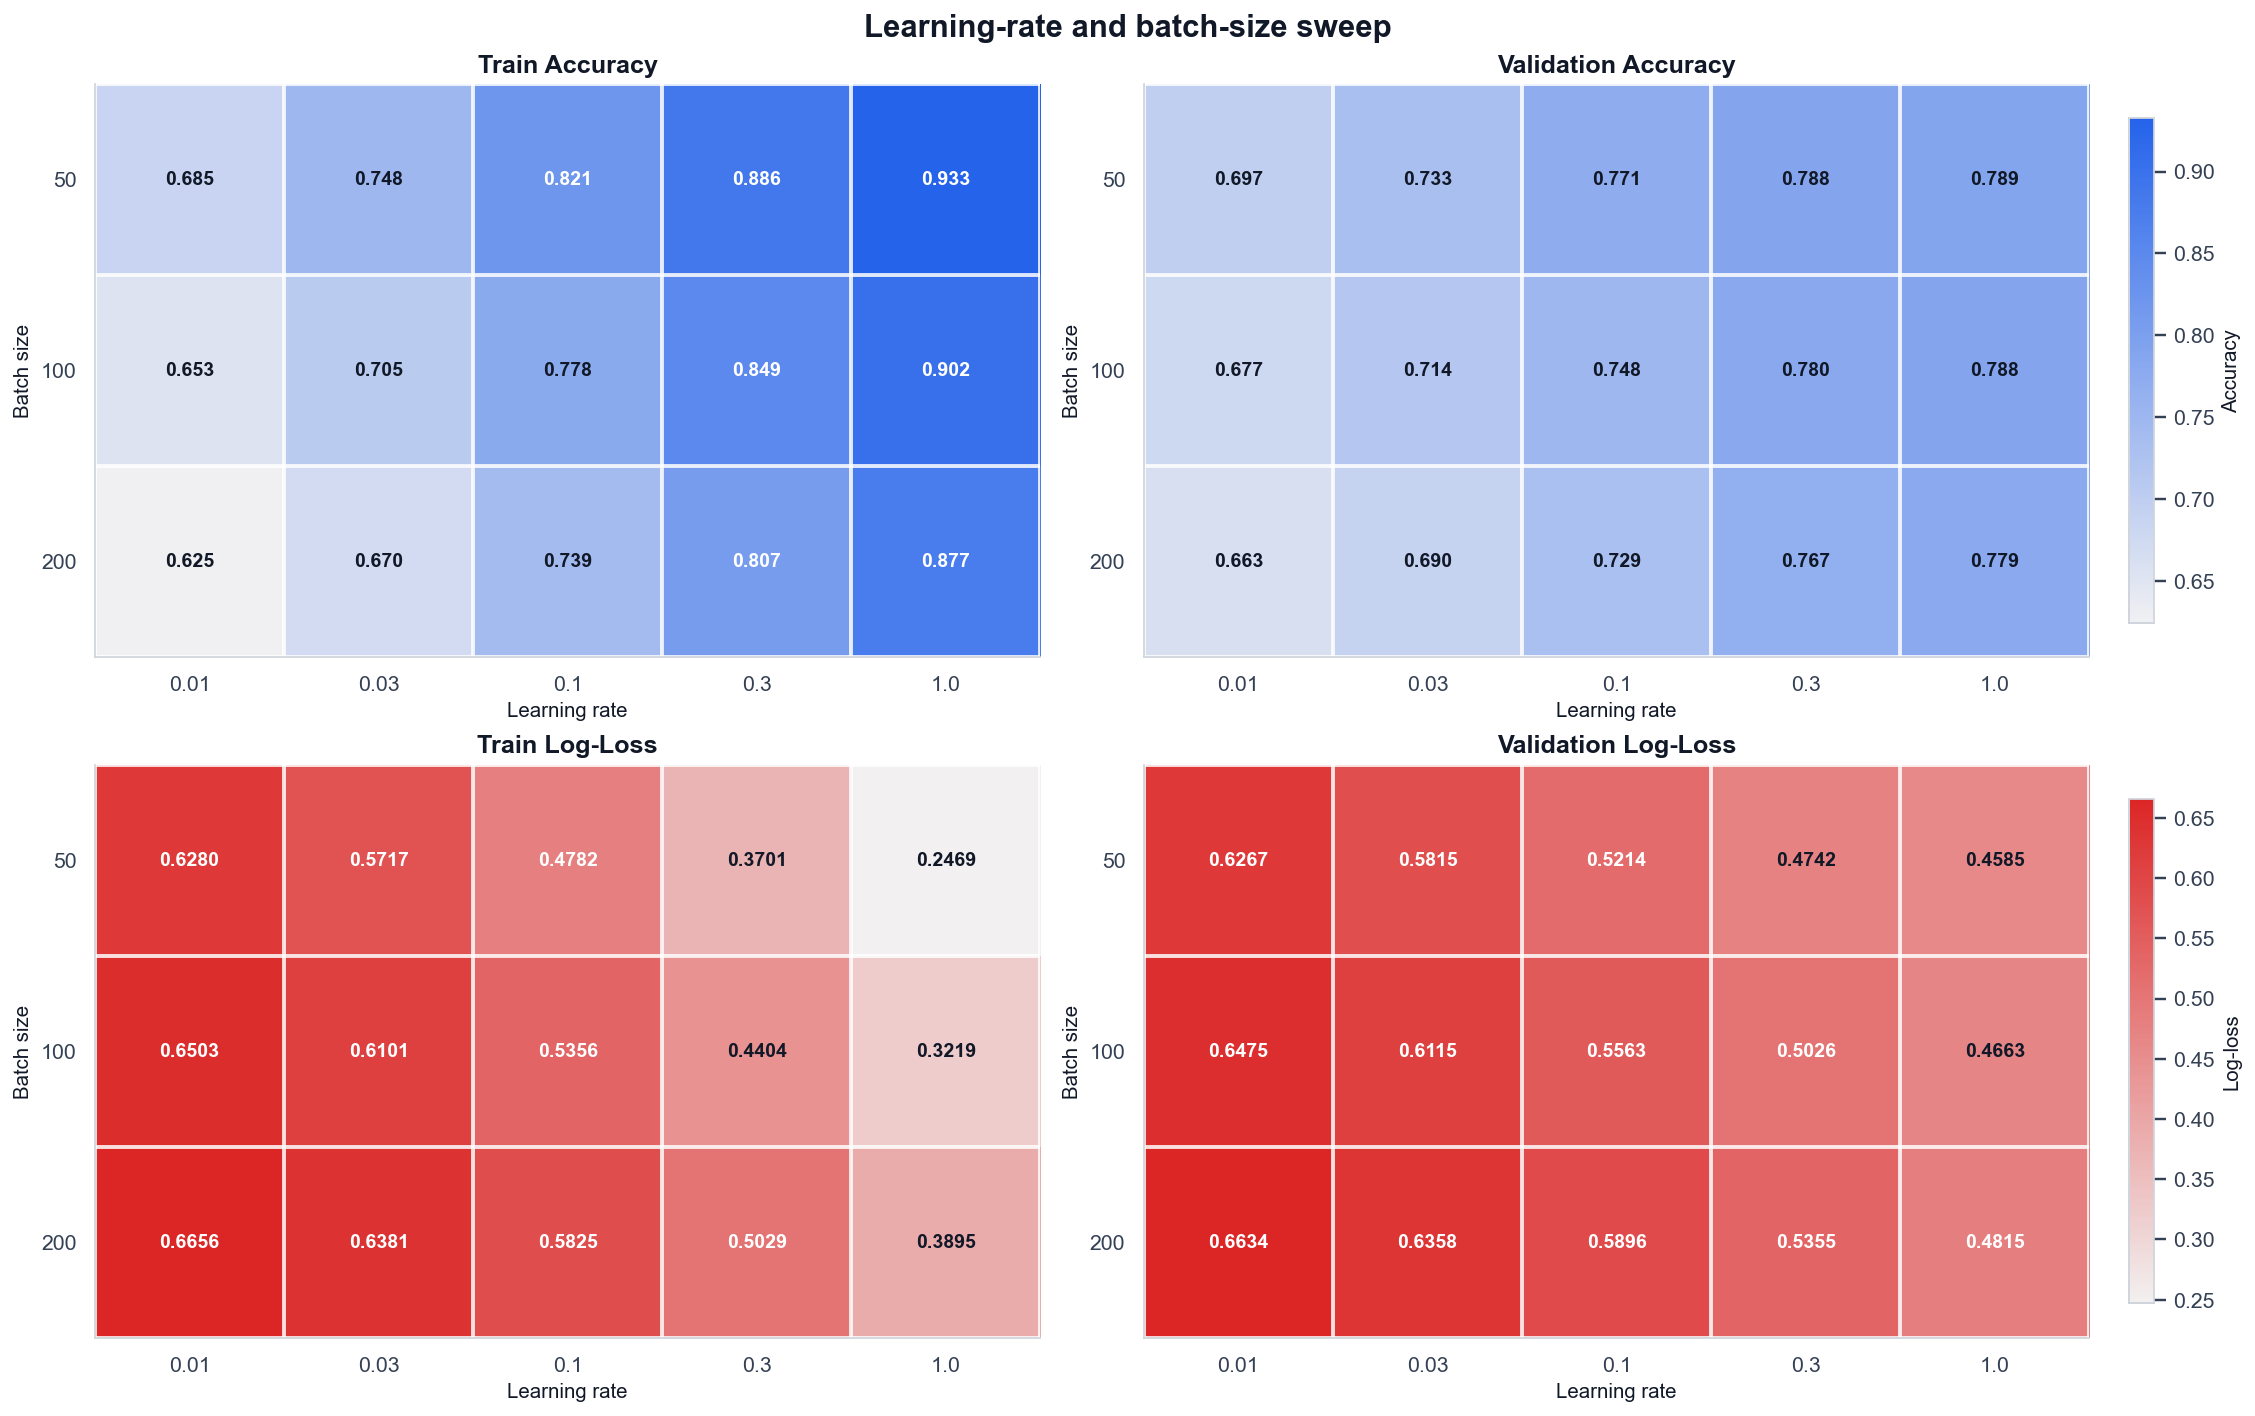


Final experiment summary:
    lr   batch  train_acc    val_acc   train_loss   val_loss  comp_ep
  0.01      50     0.6848     0.6972       0.6280     0.6267 --
  0.03      50     0.7481     0.7328       0.5717     0.5815 --
  0.10      50     0.8210     0.7706       0.4782     0.5214 --
  0.30      50     0.8857     0.7878       0.3701     0.4742       20
  1.00      50     0.9325     0.7890       0.2469     0.4585        9
  0.01     100     0.6535     0.6766       0.6503     0.6475 --
  0.03     100     0.7053     0.7144       0.6101     0.6115 --
  0.10     100     0.7776     0.7477       0.5356     0.5563 --
  0.30     100     0.8486     0.7798       0.4404     0.5026 --
  1.00     100     0.9016     0.7878       0.3219     0.4663       14
  0.01     200     0.6246     0.6628       0.6656     0.6634 --
  0.03     200     0.6698     0.6904       0.6381     0.6358 --
  0.10     200     0.7395     0.7294       0.5825     0.5896 --
  0.30     200     0.8069     0.7672       0.5029    

In [12]:

print("Using accuracy as the evaluation metric because SST-2 is a roughly balanced binary classification task.")
print(
    f"For convergence speed, I use a shared target: the first epoch whose validation loss is within "
    f"{COMPETITIVE_TOL:.0%} of the best validation loss seen in any experiment."
)

experiment_results = []
train_metric_grid = np.zeros((len(BATCH_SIZES), len(LEARNING_RATES)))
val_metric_grid = np.zeros((len(BATCH_SIZES), len(LEARNING_RATES)))
train_loss_grid = np.zeros((len(BATCH_SIZES), len(LEARNING_RATES)))
val_loss_grid = np.zeros((len(BATCH_SIZES), len(LEARNING_RATES)))
convergence_epoch_grid = np.full((len(BATCH_SIZES), len(LEARNING_RATES)), np.nan)
oscillation_grid = np.zeros((len(BATCH_SIZES), len(LEARNING_RATES)))

for i, batch_size in enumerate(BATCH_SIZES):
    for j, lr in enumerate(LEARNING_RATES):
        torch.manual_seed(RANDOM_SEED)

        _, _, _, epoch_log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=lr,
            epochs=SWEEP_EPOCHS,
            batch_size=batch_size,
            init=SWEEP_INIT_MODE,
            penalty=NO_PENALTY,
            reg_lambda=NO_REG_LAMBDA,
            metric=METRIC_NAME,
            print_metrics=False
        )

        final_log = epoch_log[-1]
        train_losses = np.array([entry['train_loss'] for entry in epoch_log], dtype=float)
        val_losses = np.array([entry['val_loss'] for entry in epoch_log], dtype=float)

        best_val_loss = float(val_losses.min())
        epoch_of_best_val_loss = int(np.argmin(val_losses) + 1)
        oscillation = float(np.std(np.diff(train_losses))) if len(train_losses) > 1 else 0.0

        train_metric_grid[i, j] = final_log['train_metric']
        val_metric_grid[i, j] = final_log['val_metric']
        train_loss_grid[i, j] = final_log['train_loss']
        val_loss_grid[i, j] = final_log['val_loss']
        oscillation_grid[i, j] = oscillation

        experiment_results.append({
            'lr': lr,
            'batch_size': batch_size,
            'lr_idx': j,
            'batch_idx': i,
            'train_metric': final_log['train_metric'],
            'val_metric': final_log['val_metric'],
            'train_loss': final_log['train_loss'],
            'val_loss': final_log['val_loss'],
            'best_val_loss': best_val_loss,
            'epoch_of_best_val_loss': epoch_of_best_val_loss,
            'oscillation': oscillation,
            'epoch_log': epoch_log
        })

global_best_val_loss = min(result['best_val_loss'] for result in experiment_results)
competitive_loss_threshold = global_best_val_loss * (1 + COMPETITIVE_TOL)

for result in experiment_results:
    val_losses = np.array([entry['val_loss'] for entry in result['epoch_log']], dtype=float)
    competitive_hits = np.where(val_losses <= competitive_loss_threshold)[0]
    competitive_epoch = float(competitive_hits[0] + 1) if len(competitive_hits) > 0 else np.nan
    result['convergence_epoch'] = competitive_epoch
    convergence_epoch_grid[result['batch_idx'], result['lr_idx']] = competitive_epoch

def plot_heatmap(ax, data, title, fmt=".3f", cmap=None, vmin=None, vmax=None):
    cmap = cmap if cmap is not None else METRIC_CMAP
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_xticks(np.arange(len(LEARNING_RATES)))
    ax.set_xticklabels(LEARNING_RATES)
    ax.set_yticks(np.arange(len(BATCH_SIZES)))
    ax.set_yticklabels(BATCH_SIZES)
    ax.set_xlabel("Learning rate")
    ax.set_ylabel("Batch size")
    ax.set_title(title)
    ax.grid(False)

    ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    low = np.nanmin(data) if vmin is None else vmin
    high = np.nanmax(data) if vmax is None else vmax
    scale = max(high - low, 1e-12)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            normalized = (data[row, col] - low) / scale
            color = "white" if normalized > 0.55 else "#111827"
            ax.text(
                col, row, format(data[row, col], fmt),
                ha="center", va="center", color=color,
                fontsize=10, fontweight="600"
            )

    return im

metric_vmin = min(train_metric_grid.min(), val_metric_grid.min())
metric_vmax = max(train_metric_grid.max(), val_metric_grid.max())
loss_vmin = min(train_loss_grid.min(), val_loss_grid.min())
loss_vmax = max(train_loss_grid.max(), val_loss_grid.max())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
fig.suptitle("Learning-rate and batch-size sweep", fontsize=16, fontweight="700")

metric_im = plot_heatmap(
    axes[0, 0], train_metric_grid,
    f"Train {METRIC_NAME.capitalize()}",
    fmt=".3f",
    cmap=METRIC_CMAP,
    vmin=metric_vmin,
    vmax=metric_vmax
)
plot_heatmap(
    axes[0, 1], val_metric_grid,
    f"Validation {METRIC_NAME.capitalize()}",
    fmt=".3f",
    cmap=METRIC_CMAP,
    vmin=metric_vmin,
    vmax=metric_vmax
)

loss_im = plot_heatmap(
    axes[1, 0], train_loss_grid,
    "Train Log-Loss",
    fmt=".4f",
    cmap=LOSS_CMAP,
    vmin=loss_vmin,
    vmax=loss_vmax
)
plot_heatmap(
    axes[1, 1], val_loss_grid,
    "Validation Log-Loss",
    fmt=".4f",
    cmap=LOSS_CMAP,
    vmin=loss_vmin,
    vmax=loss_vmax
)

fig.colorbar(metric_im, ax=axes[0, :].tolist(), shrink=0.88, pad=0.02, label=METRIC_NAME.capitalize())
fig.colorbar(loss_im, ax=axes[1, :].tolist(), shrink=0.88, pad=0.02, label="Log-loss")
sns.despine(fig=fig, left=False, bottom=False)
plt.show()

print("\nFinal experiment summary:")
print(f"{'lr':>6} {'batch':>7} {'train_acc':>10} {'val_acc':>10} {'train_loss':>12} {'val_loss':>10} {'comp_ep':>8}")
for result in experiment_results:
    convergence_text = "--" if np.isnan(result['convergence_epoch']) else f"{int(result['convergence_epoch']):>8d}"
    print(
        f"{result['lr']:>6.2f} {result['batch_size']:>7d} "
        f"{result['train_metric']:>10.4f} {result['val_metric']:>10.4f} "
        f"{result['train_loss']:>12.4f} {result['val_loss']:>10.4f} {convergence_text}"
    )

avg_val_metric_by_lr = {
    lr: float(np.mean([r['val_metric'] for r in experiment_results if r['lr'] == lr]))
    for lr in LEARNING_RATES
}
avg_convergence_by_lr = {}
for lr in LEARNING_RATES:
    lr_epochs = [r['convergence_epoch'] for r in experiment_results if r['lr'] == lr and np.isfinite(r['convergence_epoch'])]
    avg_convergence_by_lr[lr] = float(np.mean(lr_epochs)) if lr_epochs else np.nan
avg_oscillation_by_lr = {
    lr: float(np.mean([r['oscillation'] for r in experiment_results if r['lr'] == lr]))
    for lr in LEARNING_RATES
}
avg_val_metric_by_batch = {
    bs: float(np.mean([r['val_metric'] for r in experiment_results if r['batch_size'] == bs]))
    for bs in BATCH_SIZES
}
avg_oscillation_by_batch = {
    bs: float(np.mean([r['oscillation'] for r in experiment_results if r['batch_size'] == bs]))
    for bs in BATCH_SIZES
}

best_run = max(experiment_results, key=lambda r: r['val_metric'])
competitive_lrs = {lr: epoch for lr, epoch in avg_convergence_by_lr.items() if np.isfinite(epoch)}
fastest_lr = min(competitive_lrs, key=competitive_lrs.get) if competitive_lrs else None
slowest_lr = max(competitive_lrs, key=competitive_lrs.get) if competitive_lrs else None
noncompetitive_lrs = [lr for lr, epoch in avg_convergence_by_lr.items() if not np.isfinite(epoch)]
smoothest_lr = min(avg_oscillation_by_lr, key=avg_oscillation_by_lr.get)
best_batch = max(avg_val_metric_by_batch, key=avg_val_metric_by_batch.get)
smoothest_batch = min(avg_oscillation_by_batch, key=avg_oscillation_by_batch.get)
best_avg_lr = max(avg_val_metric_by_lr, key=avg_val_metric_by_lr.get)
largest_lr = max(LEARNING_RATES)

print("\nAnalysis:")
print(
    f"1. Final performance: the best validation {METRIC_NAME} was achieved with "
    f"lr={best_run['lr']} and batch_size={best_run['batch_size']}, reaching "
    f"train {METRIC_NAME}={best_run['train_metric']:.4f}, "
    f"validation {METRIC_NAME}={best_run['val_metric']:.4f}, and validation log-loss={best_run['val_loss']:.4f}."
)
if competitive_lrs:
    print(
        f"2. Convergence speed: using the shared target val_loss <= {competitive_loss_threshold:.4f} "
        f"(within {COMPETITIVE_TOL:.0%} of the global best loss {global_best_val_loss:.4f}), "
        f"lr={fastest_lr} was the fastest competitive setting (~{avg_convergence_by_lr[fastest_lr]:.1f} epochs) "
        f"and lr={slowest_lr} was the slowest among the settings that still reached that target "
        f"(~{avg_convergence_by_lr[slowest_lr]:.1f} epochs)."
    )
    if noncompetitive_lrs:
        print(
            f"The weaker learning rates {sorted(noncompetitive_lrs)} never reached that competitive-loss target, "
            f"so they should not be described as converging faster just because they flattened out early."
        )
else:
    print(
        f"2. Convergence speed: none of the tested settings reached the shared competitive-loss target of "
        f"{competitive_loss_threshold:.4f}, so the comparison must rely on final loss/accuracy only."
    )
if np.isclose(avg_val_metric_by_lr[largest_lr], avg_val_metric_by_lr[best_avg_lr]):
    print(
        f"3. Stability: all tested learning rates remained numerically stable in these runs. "
        f"The largest learning rate ({largest_lr}) was still usable and matched the strongest average validation performance, "
        f"although lr={smoothest_lr} produced the smoothest loss curves on average."
    )
else:
    print(
        f"3. Stability: all tested learning rates remained usable, but the largest learning rate ({largest_lr}) "
        f"did not give the best average validation performance. The smoothest average loss dynamics were observed at lr={smoothest_lr}."
    )
print(
    f"4. Batch size effect: batch_size={best_batch} gave the best average validation {METRIC_NAME}, while batch_size={smoothest_batch} "
    f"produced the smoothest loss dynamics. This matches the usual trade-off: smaller batches can move faster but are noisier, "
    f"while larger batches are often steadier but may converge more slowly."
)


#### **Task 1.5 — L1 Regularization and Sparsity (20 points)**



In this task, you will extend your implementation from Task 1.2 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

Using accuracy here as well because SST-2 is a roughly balanced binary classification task.
Fixed hyperparameters for lambda sweep: lr=0.1, batch_size=100, epochs=20



Initialization comparison (using lambda = 0.01):
    init   stable  train_acc    val_acc    nonzero   val_loss
   zeros     True     0.5699     0.5986       9998     0.6740
  random     True     0.5686     0.5998       9999     0.6739



Lambda sweep summary:
    lambda  train_acc    val_acc   train_loss   val_loss    nonzero
         0     0.7776     0.7477       0.5356     0.5563      10000
    0.0001     0.7618     0.7408       0.5494     0.5628       9985
     0.001     0.6897     0.7122       0.6095     0.6018       9984
      0.01     0.5686     0.5998       0.6786     0.6739       9999
       0.1     0.5234     0.5034       0.6914     0.6917      10000

Feature-selection note:
The trajectory plot below shows the five features with the largest decrease in |w| between lambda=0 and the strongest L1 run.


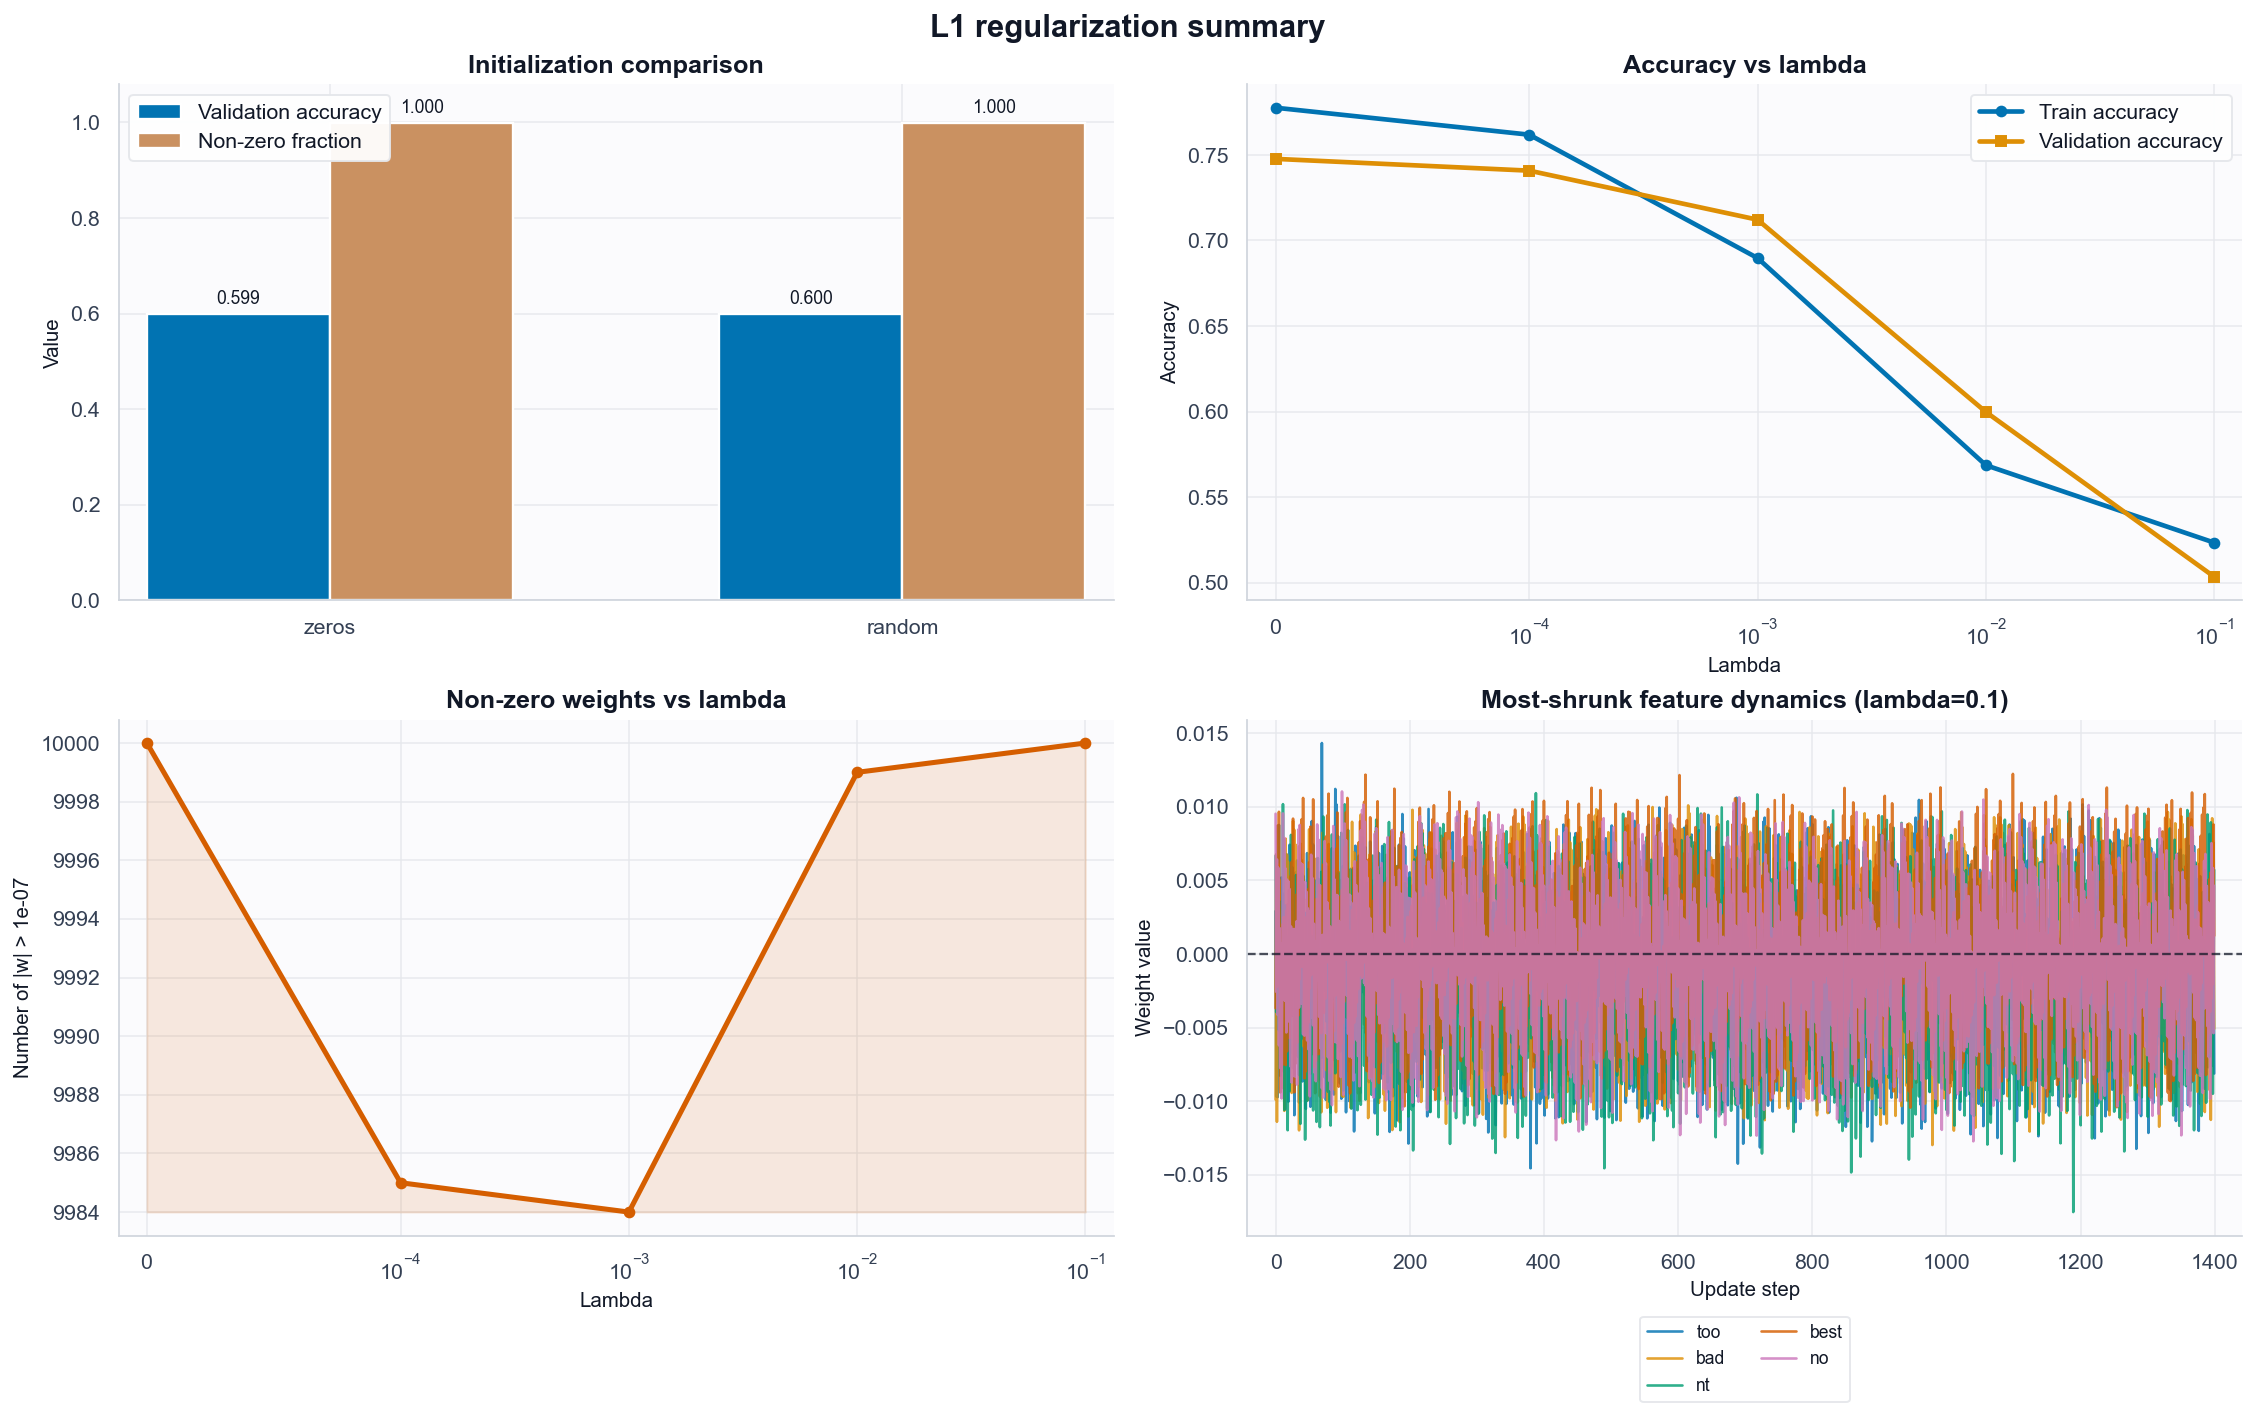


Summary:
With the strict tolerance 1e-07, the non-zero counts were [10000, 9985, 9984, 9999, 10000], so the sparsity effect was small and not monotonic in this run. The smallest count appeared at lambda=0.001 with 9984 weights above the threshold, while the best validation accuracy was obtained at lambda=0.
This still shows the main trade-off: as lambda increased, train/validation accuracy dropped, and the strongest L1 run shrank several individual coordinates. However, with plain SGD, 20 epochs, and this tolerance, the model did not become strongly sparse.
For initialization, zero init was stable=True and random init was stable=True. Their validation accuracies were 0.5986 and 0.5998, respectively, with non-zero counts 9998 and 9999. Initialization changed the exact solution only slightly here; the dominant visible effect was the performance drop as lambda increased.


In [13]:

print("Using accuracy here as well because SST-2 is a roughly balanced binary classification task.")
print(f"Fixed hyperparameters for lambda sweep: lr={L1_LR}, batch_size={L1_BATCH_SIZE}, epochs={L1_EPOCHS}")


def weight_history_to_array(history):
    if len(history) == 0:
        return np.empty((0, 0), dtype=float)
    return np.stack([entry['w'].detach().cpu().numpy().reshape(-1) for entry in history], axis=0)


def is_stable_run(epoch_log, weight_history):
    scalar_values = []
    for entry in epoch_log:
        scalar_values.extend([
            entry['train_loss'], entry['val_loss'],
            entry['train_metric'], entry['val_metric']
        ])

    scalars_ok = np.isfinite(np.array(scalar_values, dtype=float)).all()
    weights_ok = True if weight_history.size == 0 else np.isfinite(weight_history).all()
    return bool(scalars_ok and weights_ok)


def count_nonzero_weights(weights, tol=L1_TOLERANCE):
    weights = np.asarray(weights).reshape(-1)
    return int(np.sum(np.abs(weights) > tol))


def run_l1_experiment(init_mode, reg_lambda):
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train,
        X_val, y_val,
        lr=L1_LR,
        epochs=L1_EPOCHS,
        batch_size=L1_BATCH_SIZE,
        init=init_mode,
        penalty='l1',
        reg_lambda=reg_lambda,
        metric=L1_METRIC_NAME,
        print_metrics=False
    )

    weight_history = weight_history_to_array(history)
    final_weights = np.asarray(w).reshape(-1)
    final_bias = float(np.asarray(b).reshape(-1)[0])
    final_log = epoch_log[-1]

    return {
        'init': init_mode,
        'reg_lambda': reg_lambda,
        'w': final_weights,
        'b': final_bias,
        'history': history,
        'weight_history': weight_history,
        'epoch_log': epoch_log,
        'train_metric': final_log['train_metric'],
        'val_metric': final_log['val_metric'],
        'train_loss': final_log['train_loss'],
        'val_loss': final_log['val_loss'],
        'nonzero_count': count_nonzero_weights(final_weights),
        'stable': is_stable_run(epoch_log, weight_history)
    }


# 1. Compare zero vs random initialization under a moderate L1 penalty
init_results = {
    init_mode: run_l1_experiment(init_mode, INIT_COMPARE_LAMBDA)
    for init_mode in INIT_MODES
}

print(f"\nInitialization comparison (using lambda = {INIT_COMPARE_LAMBDA:g}):")
print(f"{'init':>8} {'stable':>8} {'train_acc':>10} {'val_acc':>10} {'nonzero':>10} {'val_loss':>10}")
for init_mode, result in init_results.items():
    print(
        f"{init_mode:>8} {str(result['stable']):>8} {result['train_metric']:>10.4f} "
        f"{result['val_metric']:>10.4f} {result['nonzero_count']:>10d} {result['val_loss']:>10.4f}"
    )

# 2. Sweep over lambda while keeping lr and batch_size fixed
lambda_results = [run_l1_experiment(RANDOM_INIT_MODE, reg_lambda) for reg_lambda in REG_LAMBDAS]

lambda_values = np.array([result['reg_lambda'] for result in lambda_results], dtype=float)
train_metric_values = np.array([result['train_metric'] for result in lambda_results], dtype=float)
val_metric_values = np.array([result['val_metric'] for result in lambda_results], dtype=float)
nonzero_counts = np.array([result['nonzero_count'] for result in lambda_results], dtype=int)

print("\nLambda sweep summary:")
print(f"{'lambda':>10} {'train_acc':>10} {'val_acc':>10} {'train_loss':>12} {'val_loss':>10} {'nonzero':>10}")
for result in lambda_results:
    print(
        f"{result['reg_lambda']:>10.4g} {result['train_metric']:>10.4f} {result['val_metric']:>10.4f} "
        f"{result['train_loss']:>12.4f} {result['val_loss']:>10.4f} {result['nonzero_count']:>10d}"
    )

# 3. Select features that are most strongly shrunk by the largest lambda
idx_to_word = {idx: word for word, idx in vocab.items()}
baseline_result = lambda_results[0]
strong_l1_result = lambda_results[-1]

baseline_abs = np.abs(baseline_result['w'])
strong_abs = np.abs(strong_l1_result['w'])
shrinkage = baseline_abs - strong_abs
candidate_indices = np.where((baseline_abs > FEATURE_SHRINKAGE_MIN_ABS) & (shrinkage > 0))[0]

if len(candidate_indices) > 0:
    ranked_indices = candidate_indices[np.argsort(shrinkage[candidate_indices])[::-1]]
    selection_note = (
        "The trajectory plot below shows the five features with the largest decrease in |w| "
        "between lambda=0 and the strongest L1 run."
    )
else:
    ranked_indices = np.argsort(strong_abs)
    selection_note = (
        "No feature crossed the chosen near-zero tolerance, so the trajectory plot below shows "
        "the five smallest final-magnitude weights under the strongest L1 run instead."
    )

selected_indices = ranked_indices[:min(TOP_FEATURE_COUNT, len(ranked_indices))]
selected_labels = [idx_to_word.get(int(idx), f"feature_{int(idx)}") for idx in selected_indices]

print("\nFeature-selection note:")
print(selection_note)

# 4. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
fig.suptitle("L1 regularization summary", fontsize=16, fontweight="700")

init_modes = list(init_results.keys())
init_val_metrics = [init_results[mode]['val_metric'] for mode in init_modes]
init_nonzero = [init_results[mode]['nonzero_count'] for mode in init_modes]
xpos = np.arange(len(init_modes))

acc_bars = axes[0, 0].bar(
    xpos - 0.16, init_val_metrics,
    width=0.32, label='Validation accuracy',
    color=PLOT_PALETTE[0], edgecolor="white", linewidth=1.2
)
nonzero_bars = axes[0, 0].bar(
    xpos + 0.16, np.array(init_nonzero) / len(vocab),
    width=0.32, label='Non-zero fraction',
    color=PLOT_PALETTE[5], edgecolor="white", linewidth=1.2
)
axes[0, 0].bar_label(acc_bars, fmt="%.3f", padding=3, fontsize=9)
axes[0, 0].bar_label(nonzero_bars, fmt="%.3f", padding=3, fontsize=9)
axes[0, 0].set_xticks(xpos)
axes[0, 0].set_xticklabels(init_modes)
axes[0, 0].set_ylim(0, 1.08)
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_title('Initialization comparison')
axes[0, 0].legend(loc="upper left")

axes[0, 1].plot(lambda_values, train_metric_values, marker='o', color=PLOT_PALETTE[0], label='Train accuracy')
axes[0, 1].plot(lambda_values, val_metric_values, marker='s', color=PLOT_PALETTE[1], label='Validation accuracy')
axes[0, 1].set_xscale('symlog', linthresh=1e-4)
axes[0, 1].set_xlabel('Lambda')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy vs lambda')
axes[0, 1].legend(loc="best")

axes[1, 0].plot(lambda_values, nonzero_counts, marker='o', color=PLOT_PALETTE[3], linewidth=2.6)
axes[1, 0].fill_between(lambda_values, nonzero_counts, nonzero_counts.min(), color=PLOT_PALETTE[3], alpha=0.12)
axes[1, 0].set_xscale('symlog', linthresh=1e-4)
axes[1, 0].set_xlabel('Lambda')
axes[1, 0].set_ylabel(f'Number of |w| > {L1_TOLERANCE}')
axes[1, 0].set_title('Non-zero weights vs lambda')

weight_steps = np.arange(len(strong_l1_result['weight_history']))
for color, idx, label in zip(PLOT_PALETTE, selected_indices, selected_labels):
    axes[1, 1].plot(
        weight_steps,
        strong_l1_result['weight_history'][:, idx],
        color=color, linewidth=1.35, alpha=0.82, label=label
    )
axes[1, 1].axhline(0.0, color='#111827', linewidth=1.2, linestyle='--', alpha=0.75)
axes[1, 1].set_xlabel('Update step')
axes[1, 1].set_ylabel('Weight value')
axes[1, 1].set_title(f'Most-shrunk feature dynamics (lambda={REG_LAMBDAS[-1]})')
axes[1, 1].legend(fontsize=9, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14))

for ax in axes.flat:
    ax.margins(x=0.03)

sns.despine(fig=fig)
plt.show()

# 5. Short summary paragraph
best_lambda_result = max(lambda_results, key=lambda result: result['val_metric'])
most_sparse_result = min(lambda_results, key=lambda result: result['nonzero_count'])
zeros_result = init_results[ZERO_INIT_MODE]
random_result = init_results[RANDOM_INIT_MODE]
counts_monotonic = bool(np.all(np.diff(nonzero_counts) <= 0))

if counts_monotonic:
    sparsity_message = (
        f"The number of weights above the tolerance decreased monotonically with lambda: {nonzero_counts.tolist()}."
    )
else:
    sparsity_message = (
        f"With the strict tolerance {L1_TOLERANCE}, the non-zero counts were {nonzero_counts.tolist()}, "
        f"so the sparsity effect was small and not monotonic in this run."
    )

print("\nSummary:")
print(
    f"{sparsity_message} The smallest count appeared at lambda={most_sparse_result['reg_lambda']} "
    f"with {most_sparse_result['nonzero_count']} weights above the threshold, while the best validation accuracy "
    f"was obtained at lambda={best_lambda_result['reg_lambda']}."
)
print(
    f"This still shows the main trade-off: as lambda increased, train/validation accuracy dropped, and the strongest "
    f"L1 run shrank several individual coordinates. However, with plain SGD, {L1_EPOCHS} epochs, and this tolerance, the model "
    f"did not become strongly sparse."
)
print(
    f"For initialization, zero init was stable={zeros_result['stable']} and random init was stable={random_result['stable']}. "
    f"Their validation accuracies were {zeros_result['val_metric']:.4f} and {random_result['val_metric']:.4f}, respectively, "
    f"with non-zero counts {zeros_result['nonzero_count']} and {random_result['nonzero_count']}. Initialization changed the "
    f"exact solution only slightly here; the dominant visible effect was the performance drop as lambda increased."
)


### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (30 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [14]:

# Convex bowl
def bowl(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 4 * y**2


# Six-hump Camel function
def camel(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1 * x**2 + x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_value_curves(results, title):
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    for name, (_, values) in results.items():
        ax.plot(values, color=OPTIMIZER_COLORS.get(name), label=name)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Function value")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.margins(x=0.01)
    sns.despine(fig=fig)
    plt.show()


def plot_trajectories(f, results, xlim, ylim, title, log_contours=False):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    x_grid, y_grid = np.meshgrid(x_values, y_values)

    grid = np.stack((x_grid, y_grid), axis=-1)
    grid_values = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()
    contour_values = np.log1p(grid_values - grid_values.min()) if log_contours else grid_values

    fig, ax = plt.subplots(figsize=(8.5, 6.3), constrained_layout=True)
    ax.contourf(x_grid, y_grid, contour_values, levels=34, cmap=CONTOUR_CMAP, alpha=0.18)
    ax.contour(x_grid, y_grid, contour_values, levels=28, cmap=CONTOUR_CMAP, linewidths=0.9, alpha=0.72)

    for name, (trajectory, _) in results.items():
        points = trajectory.detach().cpu().numpy()
        markevery = max(1, len(points) // 36)
        color = OPTIMIZER_COLORS.get(name)
        ax.plot(
            points[:, 0], points[:, 1],
            marker="o", markersize=4, markevery=markevery,
            linewidth=2.4, color=color, label=name
        )
        ax.scatter(points[0, 0], points[0, 1], marker="x", s=80, color=color, linewidths=2.2, zorder=5)
        ax.scatter(points[-1, 0], points[-1, 1], s=58, color=color, edgecolor="white", linewidth=1.2, zorder=6)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    ax.grid(True, color="#d1d5db", linewidth=0.7, alpha=0.55)
    sns.despine(fig=fig)
    plt.show()


def plot_trajectories_camel_log(f, results, xlim=CAMEL_XLIM, ylim=CAMEL_YLIM, title="Optimization Trajectories"):
    plot_trajectories(f, results, xlim=xlim, ylim=ylim, title=title, log_contours=True)


Convex bowl
      GD: theta=(-0.0000, 0.0000), final value=0.000000, best value=0.000000
Momentum: theta=(-0.0002, 0.0001), final value=0.000000, best value=0.000000
 AdaGrad: theta=(-0.0000, 0.0000), final value=0.000000, best value=0.000000
    Adam: theta=(0.0002, -0.0002), final value=0.000000, best value=0.000000



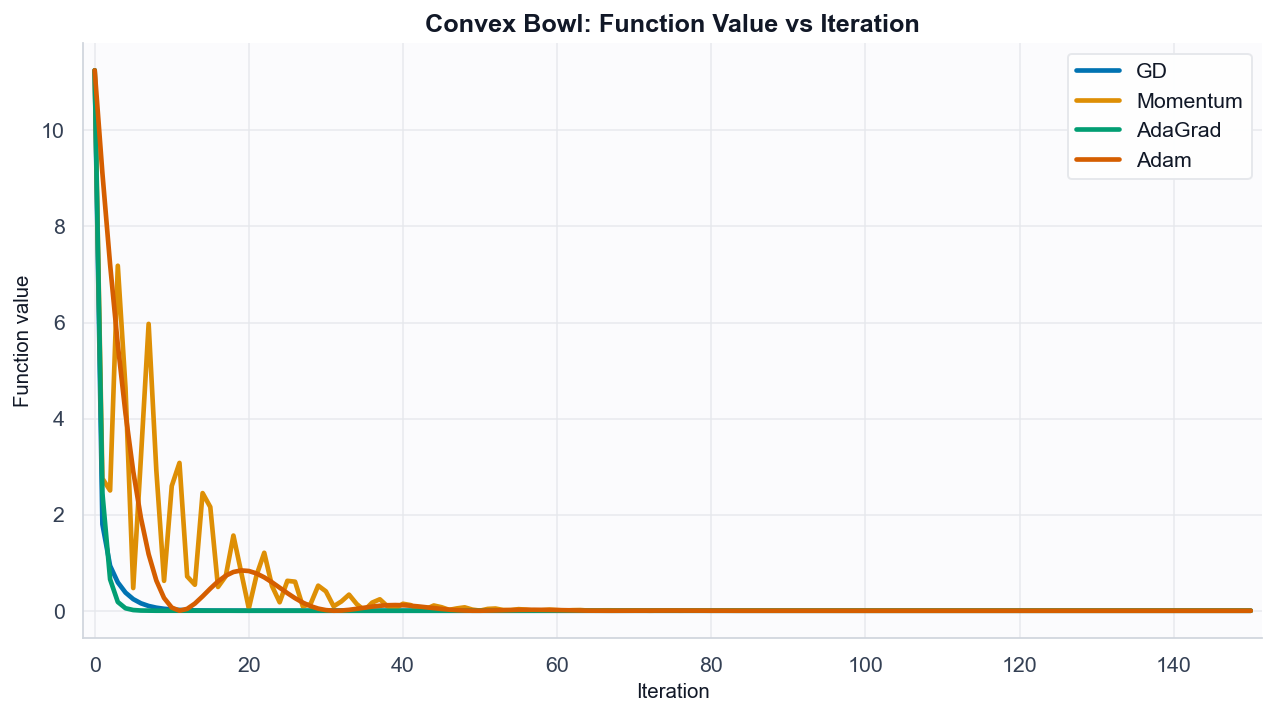

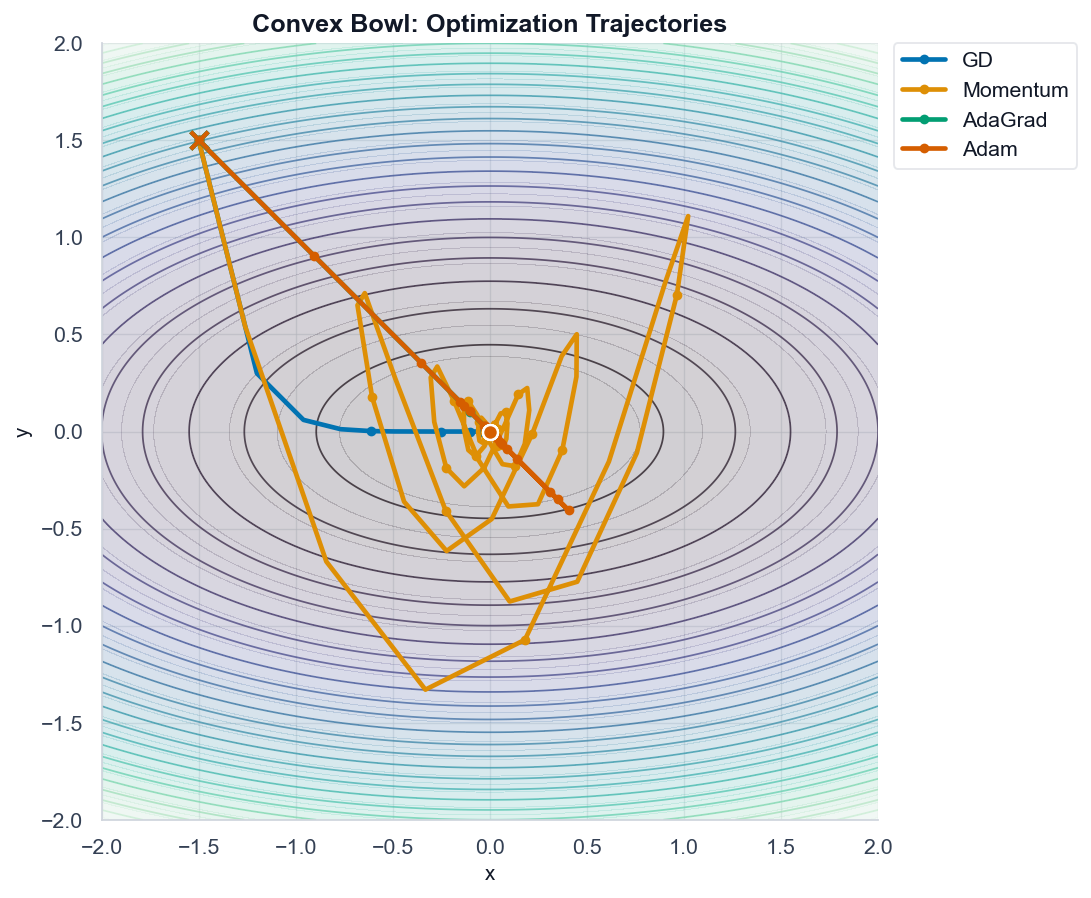

Six-hump Camel
      GD: theta=(-1.7036, 0.7961), final value=-0.215462, best value=-0.215464
Momentum: theta=(0.0898, -0.7127), final value=-1.031628, best value=-1.031628
 AdaGrad: theta=(-1.7036, 0.7961), final value=-0.215464, best value=-0.215464
    Adam: theta=(-1.7036, 0.7961), final value=-0.215464, best value=-0.215464



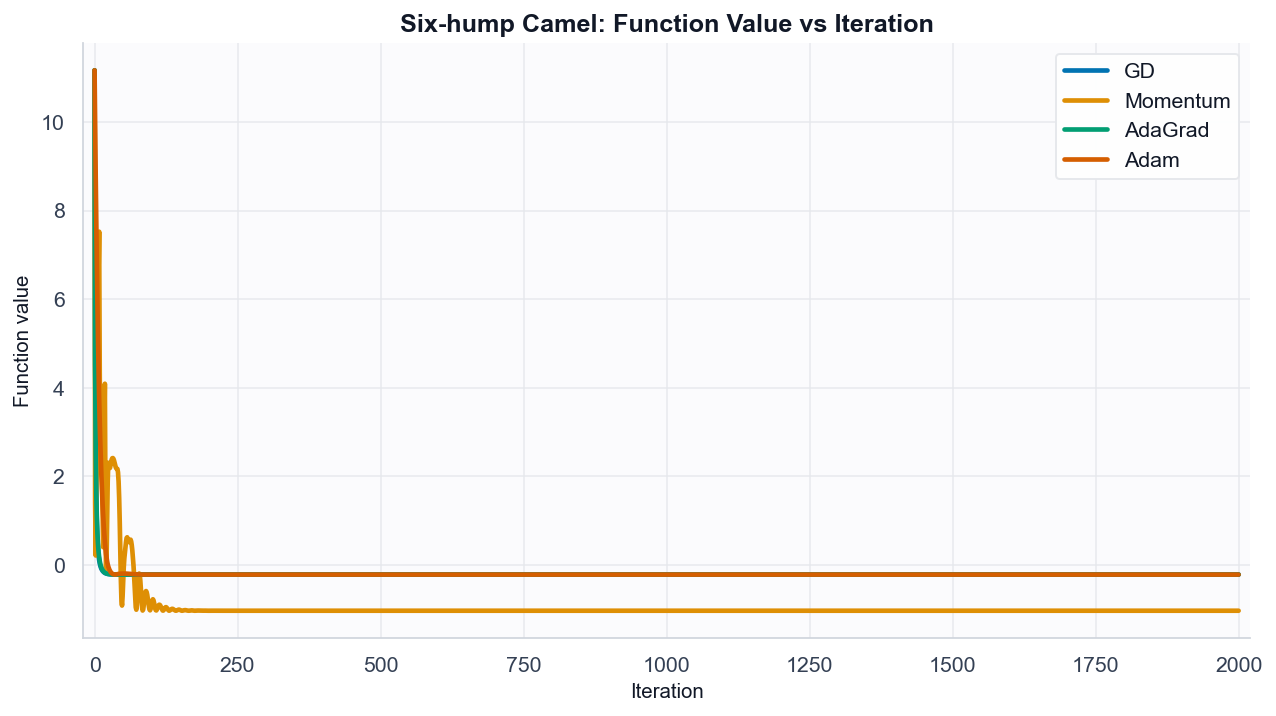

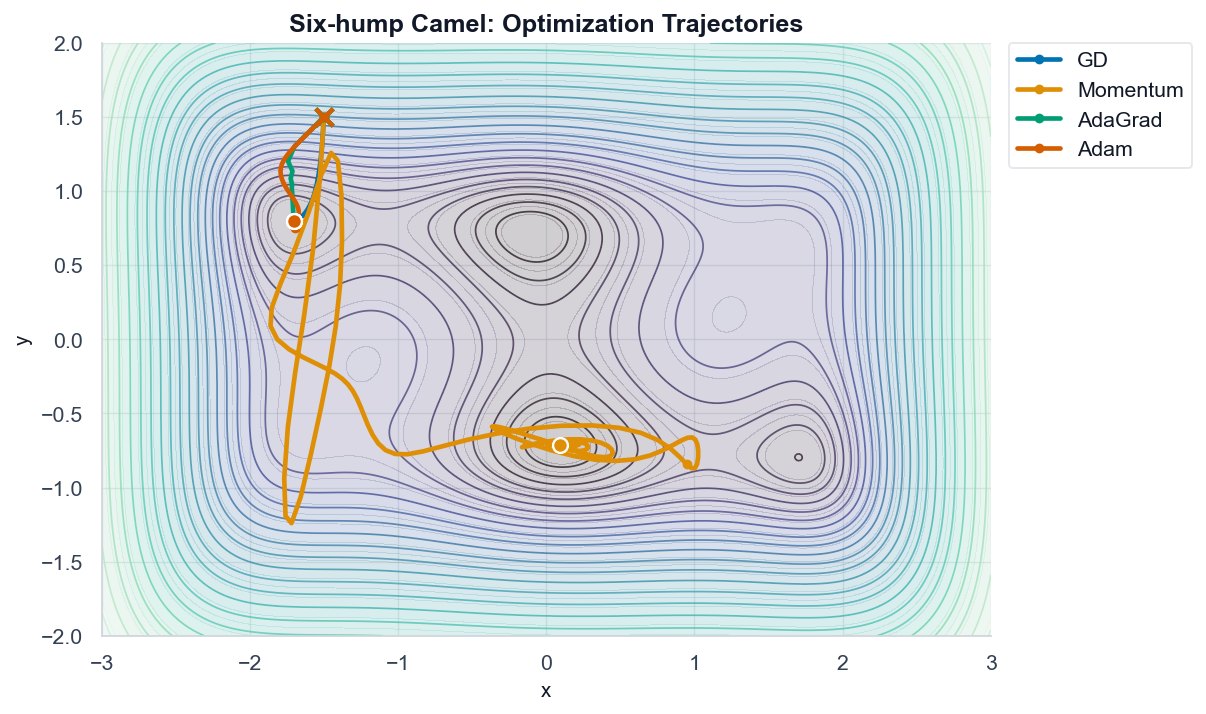

Camel sensitivity to initialization
start = (-2.0, -1.5)
        GD: theta=(-1.6071, -0.5687), final value=2.104252
  Momentum: theta=(-0.0898, 0.7127), final value=-1.031628
   AdaGrad: theta=(-1.6071, -0.5687), final value=2.104252
      Adam: theta=(-1.6071, -0.5687), final value=2.104251

start = (-1.0, 1.0)
        GD: theta=(-0.0898, 0.7127), final value=-1.031628
  Momentum: theta=(-0.0898, 0.7127), final value=-1.031628
   AdaGrad: theta=(-0.0898, 0.7127), final value=-1.031628
      Adam: theta=(-0.0898, 0.7127), final value=-1.031628

On the convex bowl, all four optimizers converge to the origin from (-1.5, 1.5), but they do it with visibly different dynamics. GD and AdaGrad reduce the loss smoothly, AdaGrad is the fastest early on because it rescales updates by the accumulated gradient magnitude, and Momentum shows the clearest oscillations before settling because its velocity keeps pushing across the steep y direction. Adam also converges quickly, but with these settings i

In [15]:
# Shared loop to keep the optimizer implementations small and avoid repetition.
def _run_optimizer(f, theta0, n_steps, step_fn):
    theta = torch.as_tensor(theta0, dtype=torch.float32).clone().detach().requires_grad_(True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]
    state = {}

    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()
        grad = theta.grad.detach().clone()

        with torch.no_grad():
            step_fn(theta, grad, step, state)

        theta.grad.zero_()
        trajectory.append(theta.detach().clone())
        values.append(f(theta).item())

    return torch.stack(trajectory), values


def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    def step_fn(theta, grad, _step, _state):
        theta -= lr * grad

    return _run_optimizer(f, theta0, n_steps, step_fn)


def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    def step_fn(theta, grad, _step, state):
        velocity = state.setdefault("velocity", torch.zeros_like(theta))
        velocity.mul_(beta).add_(grad)
        theta -= lr * velocity

    return _run_optimizer(f, theta0, n_steps, step_fn)


def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    def step_fn(theta, grad, _step, state):
        grad_sq_sum = state.setdefault("grad_sq_sum", torch.zeros_like(theta))
        grad_sq_sum.add_(grad.pow(2))
        theta -= lr * grad / (grad_sq_sum.sqrt() + eps)

    return _run_optimizer(f, theta0, n_steps, step_fn)


def adam(f, theta0, lr=DEFAULT_LR, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    def step_fn(theta, grad, step, state):
        m = state.setdefault("m", torch.zeros_like(theta))
        v = state.setdefault("v", torch.zeros_like(theta))

        m.mul_(beta1).add_((1 - beta1) * grad)
        v.mul_(beta2).add_((1 - beta2) * grad.pow(2))

        m_hat = m / (1 - beta1 ** step)
        v_hat = v / (1 - beta2 ** step)
        theta -= lr * m_hat / (v_hat.sqrt() + eps)

    return _run_optimizer(f, theta0, n_steps, step_fn)


def run_experiments(f, theta0, configs):
    return {
        name: optimizer(f, theta0, **kwargs)
        for name, (optimizer, kwargs) in configs.items()
    }


def print_summary(title, results):
    print(title)
    for name, (trajectory, values) in results.items():
        final_x, final_y = trajectory[-1].tolist()
        print(
            f"{name:>8}: theta=({final_x:.4f}, {final_y:.4f}), "
            f"final value={values[-1]:.6f}, best value={min(values):.6f}"
        )
    print()


def run_multiple_starts(f, configs, starts):
    return {
        start_label: run_experiments(f, theta0, configs)
        for start_label, theta0 in starts.items()
    }


def print_start_sensitivity(title, results_by_start):
    print(title)
    for start_label, results in results_by_start.items():
        print(f"start = {start_label}")
        for name, (trajectory, values) in results.items():
            final_x, final_y = trajectory[-1].tolist()
            print(
                f"  {name:>8}: theta=({final_x:.4f}, {final_y:.4f}), "
                f"final value={values[-1]:.6f}"
            )
        print()


# Run experiments from one shared non-optimal starting point.
theta0 = OPTIMIZER_START.clone()

# The Camel function is more sensitive, so its learning rates are tuned separately.
configs_bowl = {
    "GD": (gradient_descent, BOWL_OPTIMIZER_KWARGS["GD"]),
    "Momentum": (momentum, BOWL_OPTIMIZER_KWARGS["Momentum"]),
    "AdaGrad": (adagrad, BOWL_OPTIMIZER_KWARGS["AdaGrad"]),
    "Adam": (adam, BOWL_OPTIMIZER_KWARGS["Adam"]),
}

configs_camel = {
    "GD": (gradient_descent, CAMEL_OPTIMIZER_KWARGS["GD"]),
    "Momentum": (momentum, CAMEL_OPTIMIZER_KWARGS["Momentum"]),
    "AdaGrad": (adagrad, CAMEL_OPTIMIZER_KWARGS["AdaGrad"]),
    "Adam": (adam, CAMEL_OPTIMIZER_KWARGS["Adam"]),
}

results_bowl = run_experiments(bowl, theta0, configs_bowl)
results_camel = run_experiments(camel, theta0, configs_camel)

print_summary("Convex bowl", results_bowl)
plot_value_curves(results_bowl, "Convex Bowl: Function Value vs Iteration")
plot_trajectories(bowl, results_bowl, xlim=BOWL_XLIM, ylim=BOWL_YLIM, title="Convex Bowl: Optimization Trajectories")

print_summary("Six-hump Camel", results_camel)
plot_value_curves(results_camel, "Six-hump Camel: Function Value vs Iteration")
plot_trajectories_camel_log(camel, results_camel, title="Six-hump Camel: Optimization Trajectories")

# Extra Camel runs to show that the final basin depends on initialization.
camel_sensitivity_results = run_multiple_starts(camel, configs_camel, CAMEL_SENSITIVITY_STARTS)
print_start_sensitivity("Camel sensitivity to initialization", camel_sensitivity_results)

gd_camel_final = results_camel["GD"][0][-1].tolist()
momentum_camel_final = results_camel["Momentum"][0][-1].tolist()
hard_start_gd_final = camel_sensitivity_results["(-2.0, -1.5)"]["GD"][0][-1].tolist()
hard_start_momentum_final = camel_sensitivity_results["(-2.0, -1.5)"]["Momentum"][0][-1].tolist()
easy_start_gd_final = camel_sensitivity_results["(-1.0, 1.0)"]["GD"][0][-1].tolist()

analysis_text = f"""
On the convex bowl, all four optimizers converge to the origin from {tuple(theta0.tolist())}, but they do it with visibly different dynamics. GD and AdaGrad reduce the loss smoothly, AdaGrad is the fastest early on because it rescales updates by the accumulated gradient magnitude, and Momentum shows the clearest oscillations before settling because its velocity keeps pushing across the steep y direction. Adam also converges quickly, but with these settings it is less monotone than AdaGrad on this simple convex surface.

On the Six-hump Camel function, the geometry matters much more. From the main start {tuple(theta0.tolist())}, GD, AdaGrad, and Adam all settle into a local minimum near ({gd_camel_final[0]:.4f}, {gd_camel_final[1]:.4f}) with value about {results_camel['GD'][1][-1]:.4f}, while Momentum reaches the global minimum near ({momentum_camel_final[0]:.4f}, {momentum_camel_final[1]:.4f}) with value about {results_camel['Momentum'][1][-1]:.4f}. The extra multi-start check makes the initialization dependence explicit: from (-2.0, -1.5), GD gets trapped near ({hard_start_gd_final[0]:.4f}, {hard_start_gd_final[1]:.4f}) while Momentum still reaches a global minimum near ({hard_start_momentum_final[0]:.4f}, {hard_start_momentum_final[1]:.4f}); from (-1.0, 1.0), even GD reaches a global minimum near ({easy_start_gd_final[0]:.4f}, {easy_start_gd_final[1]:.4f}). This shows that hyperparameters do not transfer equally well between the two functions and that none of these first-order methods guarantees a global optimum on a non-convex surface.
""".strip()

print(analysis_text)


### **Knowledge Bonus.** An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent



The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\text{ if } w_i > 0,\\
+\alpha\lambda,\text{ if } w_i < 0,
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto z_i = w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
z_i - \alpha\lambda,\text{ if } z_i \geqslant \alpha\lambda,\\
0,\text{ if } |z_i| < \alpha\lambda,\\
z_i + \alpha\lambda,\text{ if } z_i \leqslant -\alpha\lambda,\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$

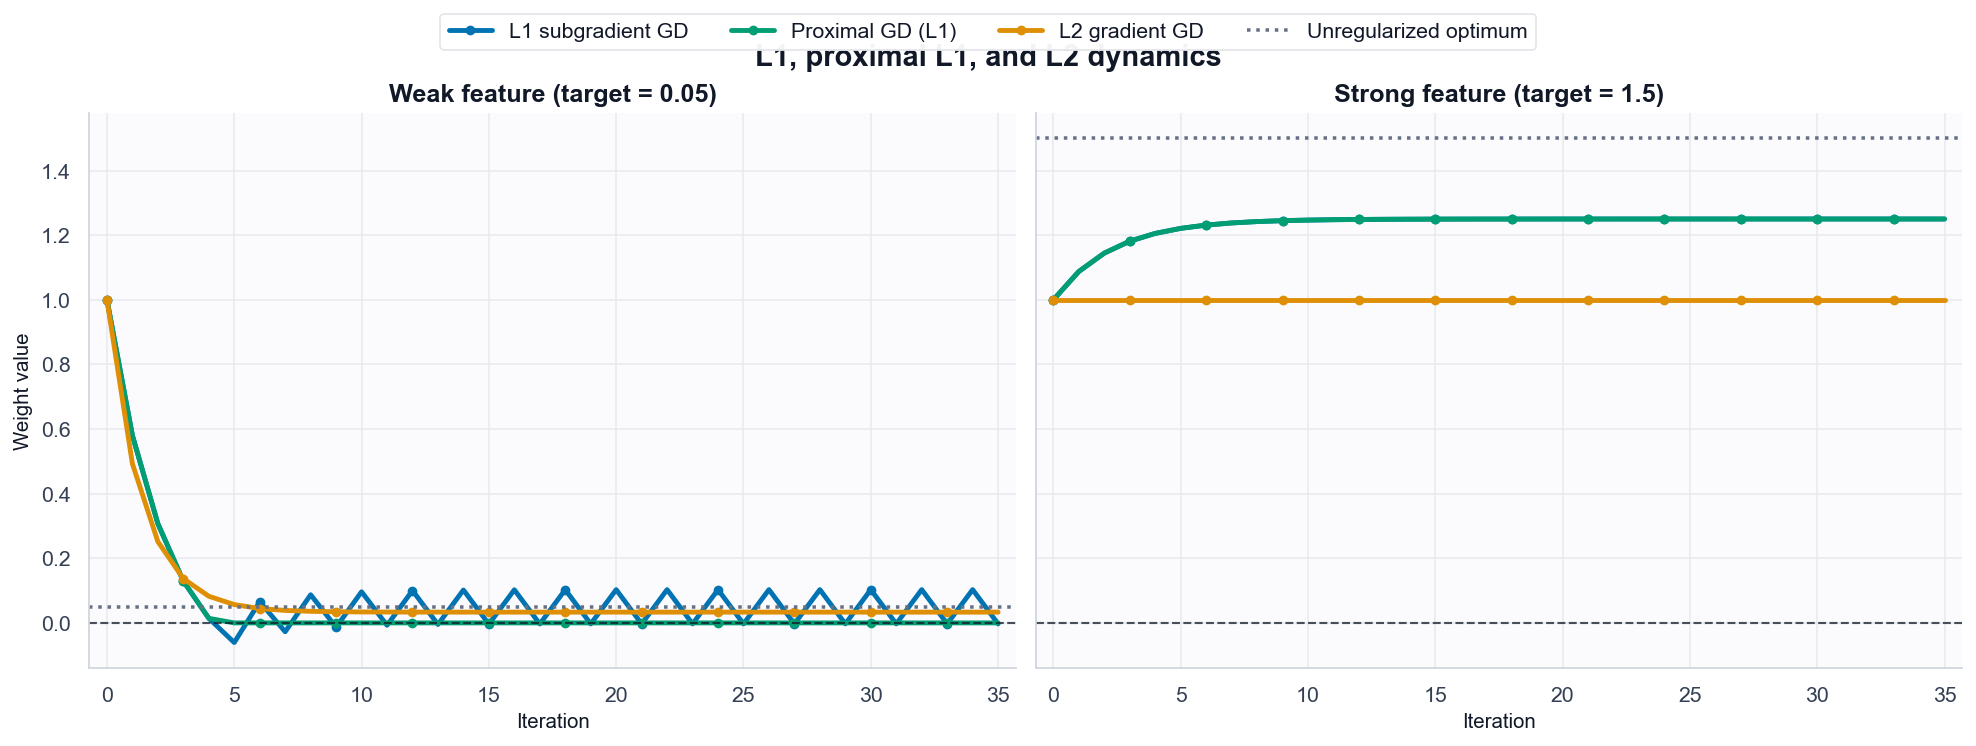

Toy setup: smooth loss = 0.5 * (w - target)^2, alpha=0.35, lambda=0.25, start=1.0

Weak feature
  L1 subgradient GD  final_w = -0.0030, first exact zero = never
  Proximal GD (L1)   final_w =  0.0000, first exact zero = 5
  L2 gradient GD     final_w =  0.0333, first exact zero = never
  Proximal step from w=0 gives 0.0000

Strong feature
  L1 subgradient GD  final_w =  1.2500, first exact zero = never
  Proximal GD (L1)   final_w =  1.2500, first exact zero = never
  L2 gradient GD     final_w =  1.0000, first exact zero = never
  Proximal step from w=0 gives 0.4375

Interpretation: for the weak feature, naive L1 subgradient descent oscillates around zero, proximal GD snaps to exact zero, and L2 shrinks smoothly but usually stays non-zero. For the strong feature, all methods keep a non-zero weight because the data gradient is strong enough to overcome the regularizer.


In [16]:

# Toy 1D example: smooth loss = 0.5 * (w - target)^2
# Small |target| means the feature is weak; large |target| means it is important.


def smooth_grad(w, target):
    return w - target


def l1_subgradient_step(w, target, alpha, reg_lambda):
    return w - alpha * (smooth_grad(w, target) + reg_lambda * np.sign(w))


def proximal_l1_step(w, target, alpha, reg_lambda):
    z = w - alpha * smooth_grad(w, target)
    return np.sign(z) * np.maximum(np.abs(z) - alpha * reg_lambda, 0.0)


def l2_step(w, target, alpha, reg_lambda):
    return w - alpha * (smooth_grad(w, target) + 2 * reg_lambda * w)


def run_trajectory(step_fn, target, w0, alpha, reg_lambda, n_steps):
    trajectory = [w0]
    w = w0
    for _ in range(n_steps):
        w = step_fn(w, target, alpha, reg_lambda)
        trajectory.append(w)
    return np.array(trajectory, dtype=float)


def first_zero_hit(trajectory, tol=ZERO_HIT_TOLERANCE):
    hits = np.where(np.abs(trajectory) <= tol)[0]
    return None if len(hits) == 0 else int(hits[0])


methods = {
    "L1 subgradient GD": l1_subgradient_step,
    "Proximal GD (L1)": proximal_l1_step,
    "L2 gradient GD": l2_step,
}

results = {
    feature_name: {
        method_name: run_trajectory(step_fn, target, TOY_W0, TOY_ALPHA, TOY_REG_LAMBDA, TOY_N_STEPS)
        for method_name, step_fn in methods.items()
    }
    for feature_name, target in TOY_TARGETS.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)
fig.suptitle("L1, proximal L1, and L2 dynamics", fontsize=15, fontweight="700")
steps = np.arange(TOY_N_STEPS + 1)

for ax, (feature_name, target) in zip(axes, TOY_TARGETS.items()):
    for method_name, trajectory in results[feature_name].items():
        ax.plot(
            steps, trajectory,
            marker='o', markersize=4, markevery=3,
            linewidth=2.5, color=REGULARIZATION_COLORS.get(method_name),
            label=method_name
        )
    ax.axhline(0.0, color='#111827', linestyle='--', linewidth=1.1, alpha=0.75)
    ax.axhline(
        target, color='#667085', linestyle=':', linewidth=1.8,
        label='Unregularized optimum' if feature_name == 'Weak feature' else None
    )
    ax.set_title(f"{feature_name} (target = {target})")
    ax.set_xlabel("Iteration")
    ax.margins(x=0.02)

axes[0].set_ylabel("Weight value")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=4)
sns.despine(fig=fig)
plt.show()

print(f"Toy setup: smooth loss = 0.5 * (w - target)^2, alpha={TOY_ALPHA}, lambda={TOY_REG_LAMBDA}, start={TOY_W0}")
print()

for feature_name, target in TOY_TARGETS.items():
    print(feature_name)
    for method_name, trajectory in results[feature_name].items():
        zero_hit = first_zero_hit(trajectory)
        zero_text = 'never' if zero_hit is None else str(zero_hit)
        print(
            f"  {method_name:<18} final_w = {trajectory[-1]:>7.4f}, "
            f"first exact zero = {zero_text}"
        )

    from_zero = proximal_l1_step(0.0, target, TOY_ALPHA, TOY_REG_LAMBDA)
    print(f"  Proximal step from w=0 gives {from_zero:.4f}")
    print()

print(
    "Interpretation: for the weak feature, naive L1 subgradient descent oscillates around zero, proximal GD snaps to exact zero, and L2 shrinks smoothly but usually stays non-zero. "
    "For the strong feature, all methods keep a non-zero weight because the data gradient is strong enough to overcome the regularizer."
)
